# PRACTICAL R PLOTTING

R has two major plotting systems:

- Base R Graphics → Quick & simple

- ggplot2 (Grammar of Graphics) → Professional & flexible

## SAMPLE DATASET FOR PRACTICAL

In [172]:
# Create sample dataset
data <- data.frame(
  Name = c("A", "B", "C", "D", "E"),
  Sales = c(200, 450, 300, 500, 400),
  Profit = c(50, 120, 80, 150, 100),
  Region = c("North", "South", "East", "West", "North")
)

In [173]:
# Printing out the result of the data created
data

Name,Sales,Profit,Region
<chr>,<dbl>,<dbl>,<chr>
A,200,50,North
B,450,120,South
C,300,80,East
D,500,150,West
E,400,100,North


# BASIC PLOTS IN BASE R

🔹 1. Scatter Plot (Relationship Between Variables)

- Use Case: Correlation, trend detection

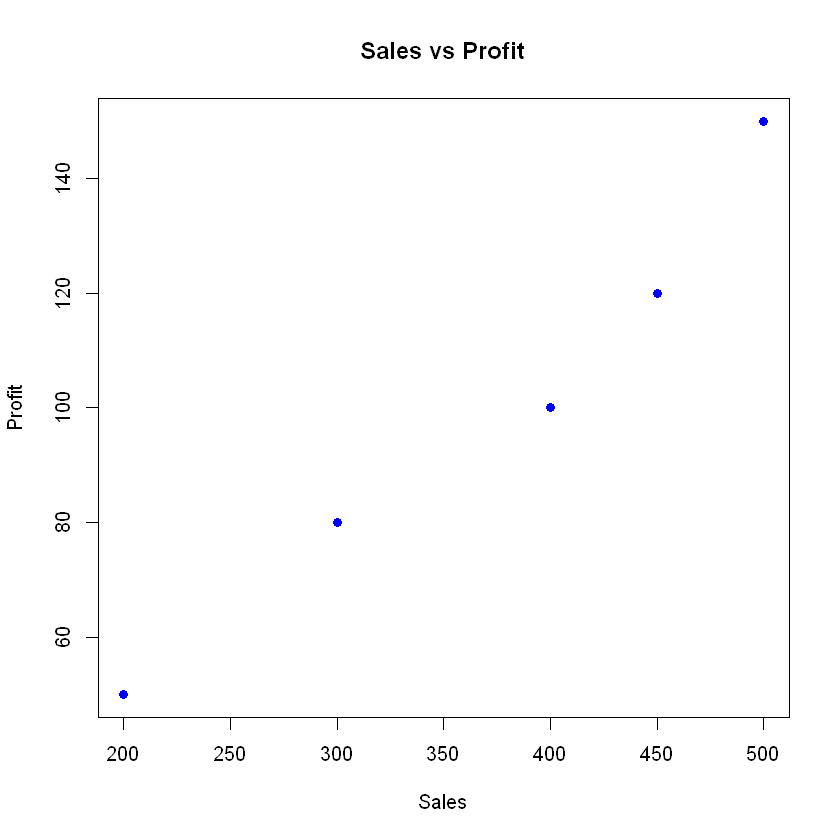

In [174]:
plot(data$Sales, data$Profit,
     main = "Sales vs Profit",
     xlab = "Sales",
     ylab = "Profit",
     col = "blue",
     pch = 19)

🔹 2. Line Plot (Trend Over Time)

- Use Case: Time series analysis

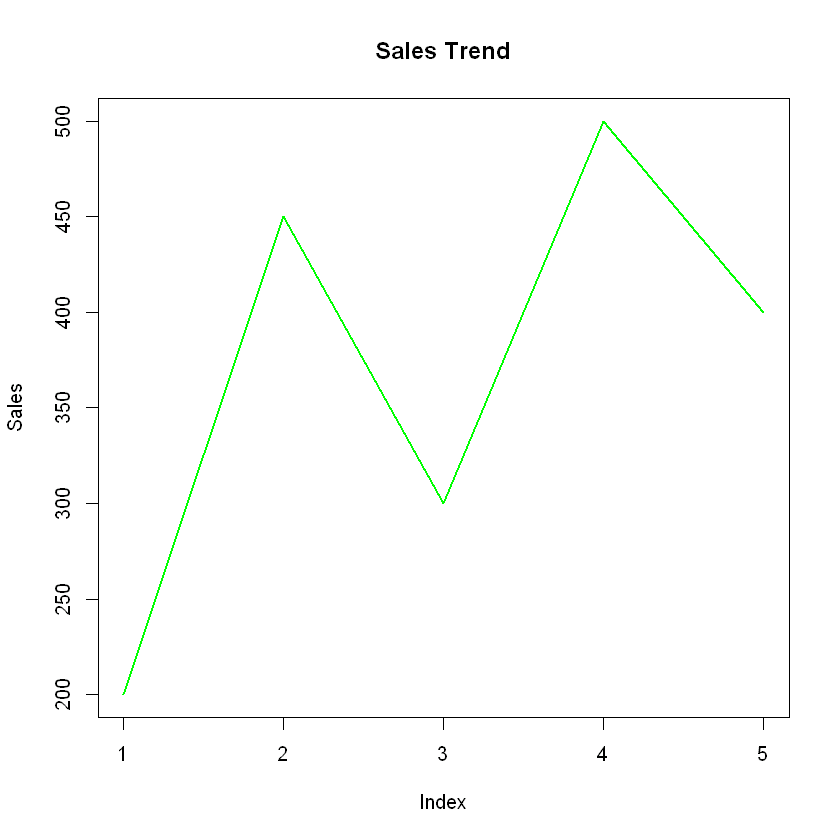

In [175]:
plot(data$Sales, type = "l",
     main = "Sales Trend",
     xlab = "Index",
     ylab = "Sales",
     col = "green",
     lwd = 2)

| Type  | Meaning                       |
| ----- | ----------------------------- |
| `"p"` | Points (default scatter)      |
| `"l"` | Line                          |
| `"b"` | Both (points + line)          |
| `"o"` | Overplotted                   |
| `"h"` | Histogram-like vertical lines |

🔹 3. Bar Chart (Categorical Comparison)

- Use Case: Category comparison

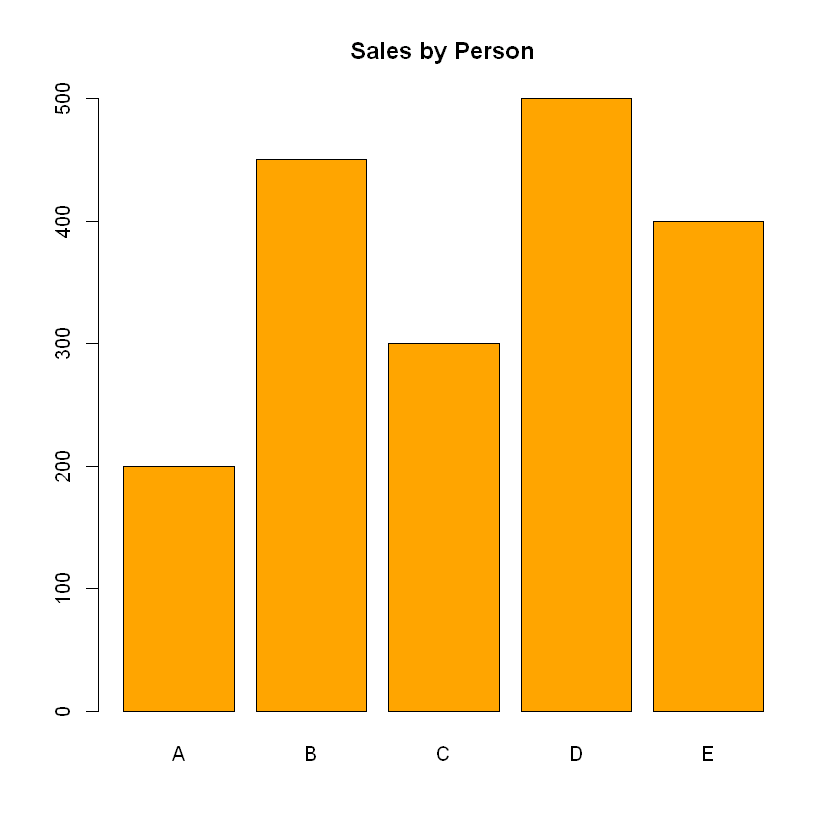

In [176]:
barplot(data$Sales,
        names.arg = data$Name, # names.arg stands for "names of the arguments (bars)" and it controls the label shown on the X-axis (under each bar)
        main = "Sales by Person",
        col = "orange")

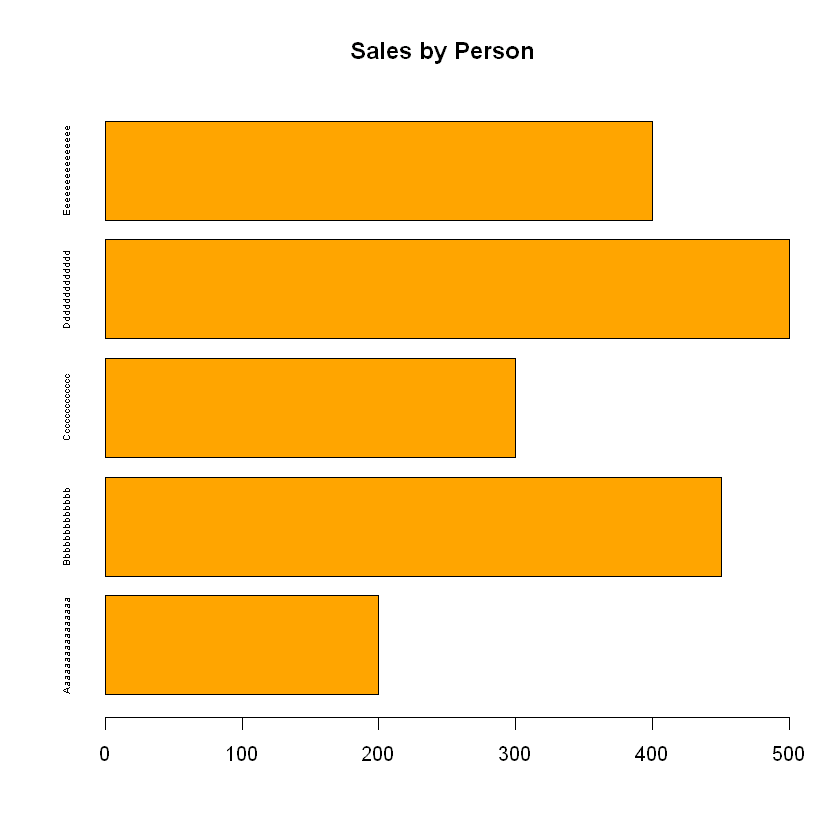

In [177]:
# Create sample dataset
data <- data.frame(
  Name = c("Aaaaaaaaaaaaaaaa", "Bbbbbbbbbbbbb", "Ccccccccccccc", "Ddddddddddddd", "Eeeeeeeeeeeeeee"),
  Sales = c(200, 450, 300, 500, 400),
  Profit = c(50, 120, 80, 150, 100),
  Region = c("North", "South", "East", "West", "North")
)

# Horizontal Bar Chart - It is easier to read when labels are long
barplot(data$Sales,
        names.arg = data$Name,
        main = "Sales by Person",
        col = "orange",
        cex.names = 0.5, # cex.names controls the label size
        horiz = TRUE)

🔹 4. Histogram (Distribution)

- Use Case: Frequency distribution

A histogram groups numbers into ranges and shows how many values fall into each range.

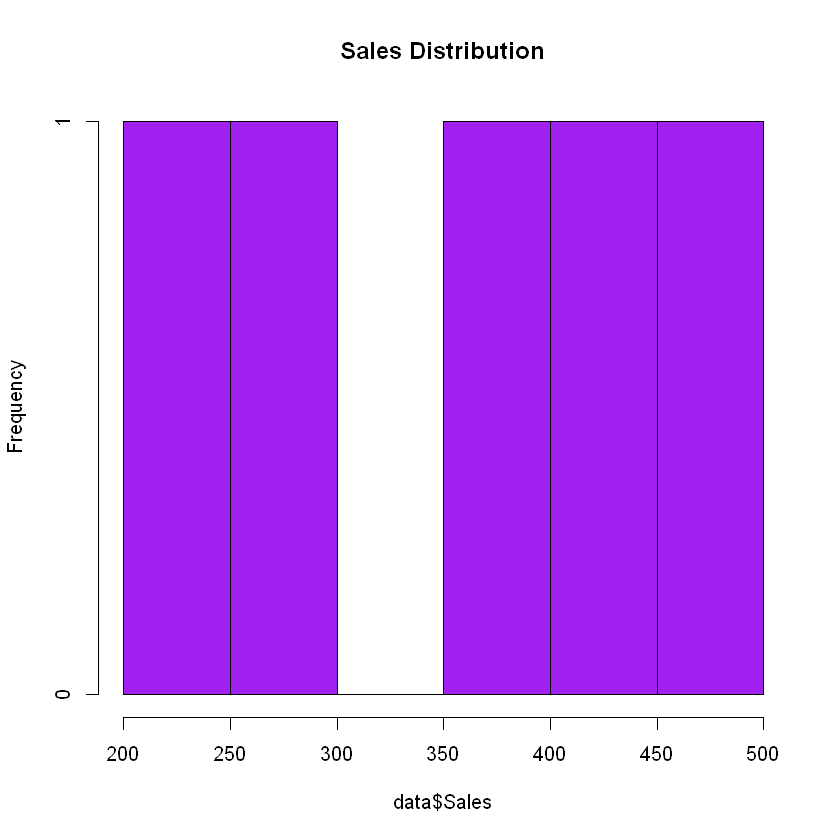

In [178]:
hist(data$Sales,                   # hist() => This function creates a histogram
     main = "Sales Distribution",  
     col = "purple",
     breaks = 5)                   # breaks = 5 => Divide the data into five(5) intervals (bins)
# NOTE:- What the graph shows
# X-axis => ranges of sales
# Y-axis => frequency (count)

🔹 5. Box Plot (Outliers & Spread)

Box Plot is a graphical visualization which summmarizes data into a box-and-whisker-plot using the five (5) key statistics displayed in the table below.

- Use Case: Detect outliers

| Component   | Meaning        |
| ----------- | -------------- |
| Minimum     | Lowest value   |
| Q1 (25%)    | Lower quartile |
| Median (Q2) | Middle value   |
| Q3 (75%)    | Upper quartile |
| Maximum     | Highest value  |

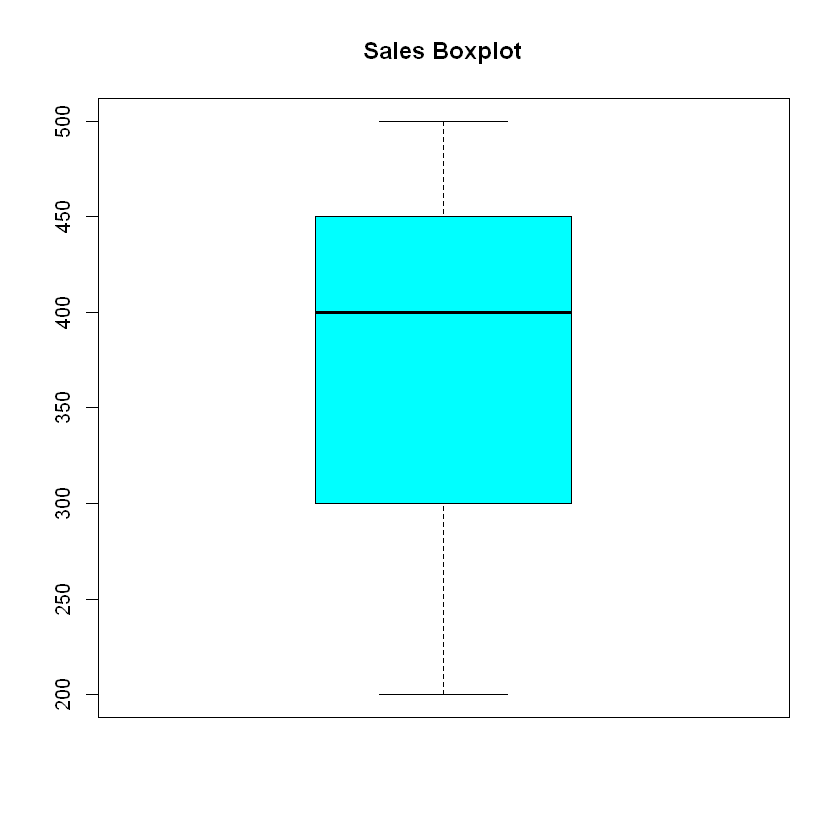

In [179]:
boxplot(data$Sales,
        main = "Sales Boxplot",
        col = "cyan")

NOTE => 

From the result above;

1. Median (Middle Line) which is around 400. The horizontal line inside the box.

2. The Box (Q1 & Q3)

- Bottom of box => ~300 (Q1)

- Top of box => ~450 (Q3)

The box contains 50% of the data.

3. Whiskers (Lines Outside Box)

- Lower whiskers => ~200

- Upper Whiskers => ~500

The whiskers shows the range of the data



Working with outliers in R Box Plots

The outlier points outside whiskers.

In summary of the box plot; 

- The box shows where most of the data lies. 

- The line inside is the median.

- The whiskers show the spread

- Any dots outside are outliers.

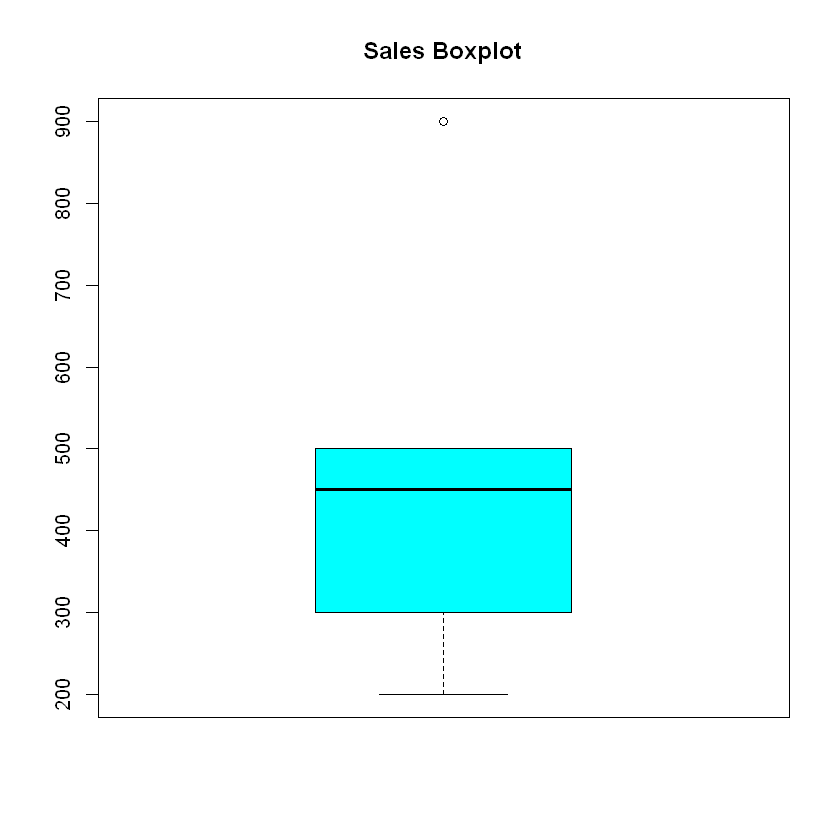

In [180]:
# Create sample dataset
data <- data.frame(
  Name = c("A", "B", "C", "D", "E"),
  Sales = c(200, 450, 300, 500, 900),
  Profit = c(50, 120, 80, 150, 100),
  Region = c("North", "South", "East", "West", "North")
)

boxplot(data$Sales,
        main = "Sales Boxplot",
        col = "cyan")

🔹 6. Pie Chart (Proportion)

- Use Case: Percentage contribution

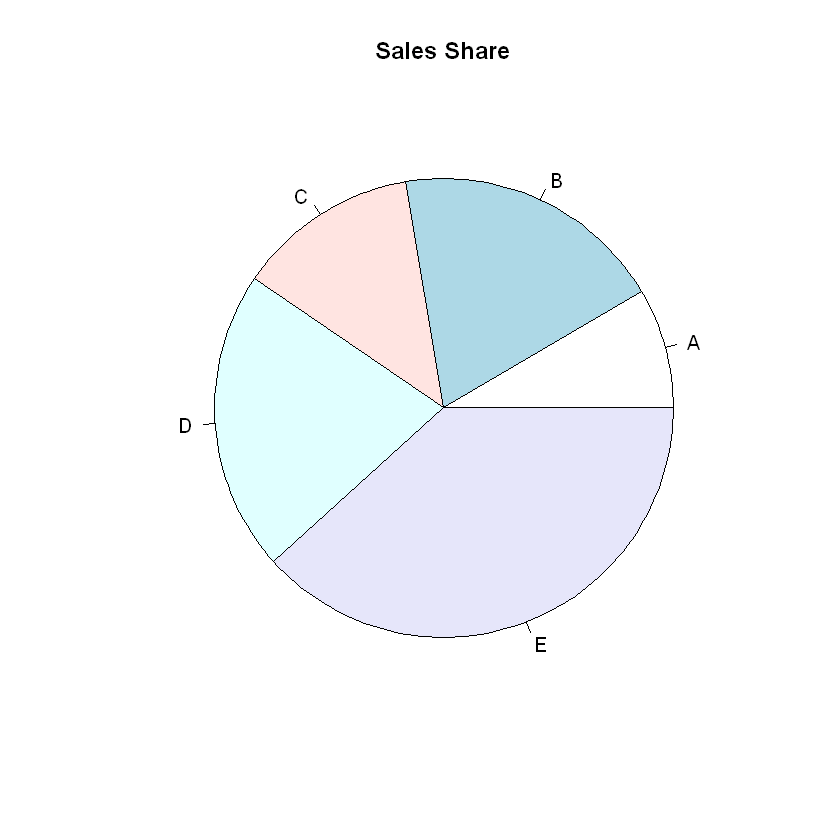

In [181]:
pie(data$Sales,
    labels = data$Name,
    main = "Sales Share")

# ADVANCED VISUALIZATION WITH ggplot2

Install and load:

In [182]:
install.packages("ggplot2")
library(ggplot2)

Warning message:
"package 'ggplot2' is in use and will not be installed"


🔹 1. Scatter Plot with ggplot2

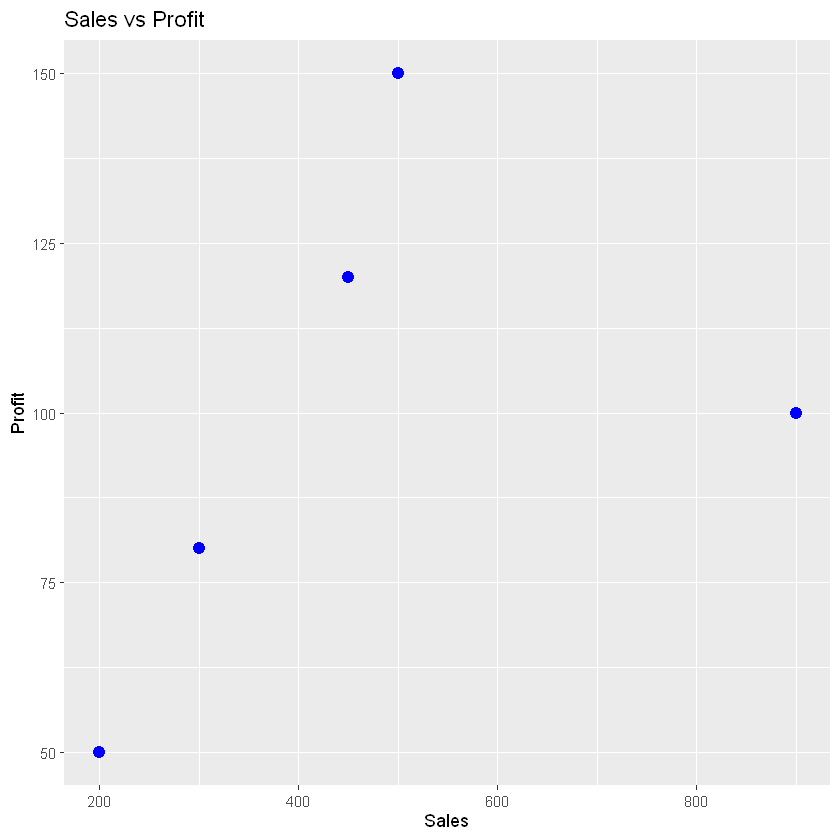

In [183]:
ggplot(data, aes(x = Sales, y = Profit)) +
  geom_point(color = "blue", size = 3) +
  ggtitle("Sales vs Profit")

🔹 2. Add Regression Line (VERY IMPORTANT FOR DATA SCIENCE)

`geom_smooth()` using formula = 'y ~ x'


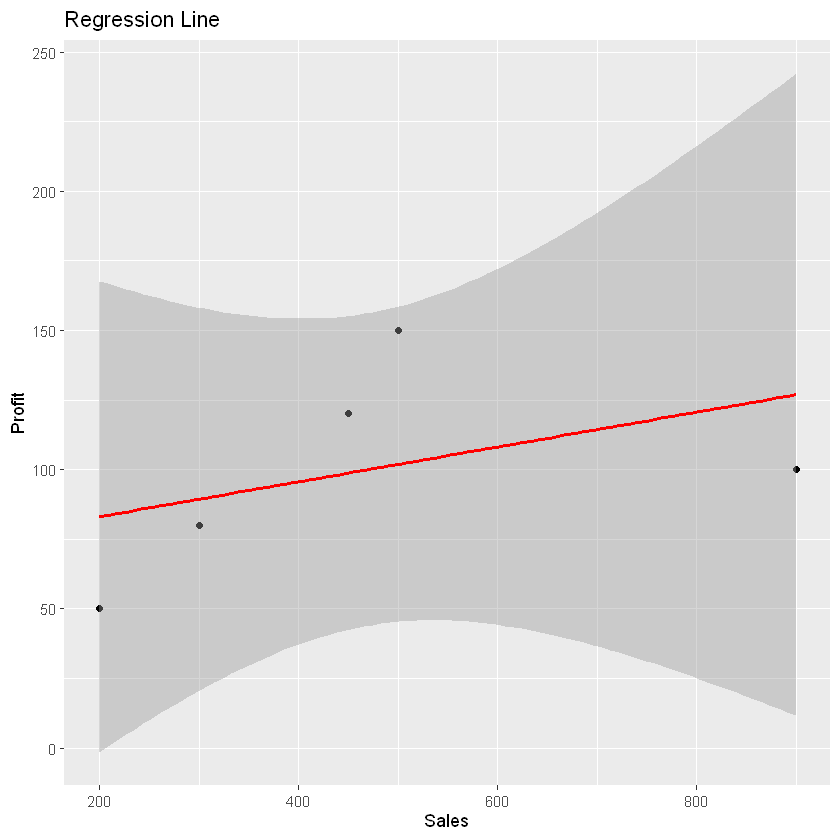

In [184]:
ggplot(data, aes(x = Sales, y = Profit)) +
  geom_point() +
  geom_smooth(method = "lm", color = "red") +
  ggtitle("Regression Line")

🔹 3. Bar Chart (Grouped)

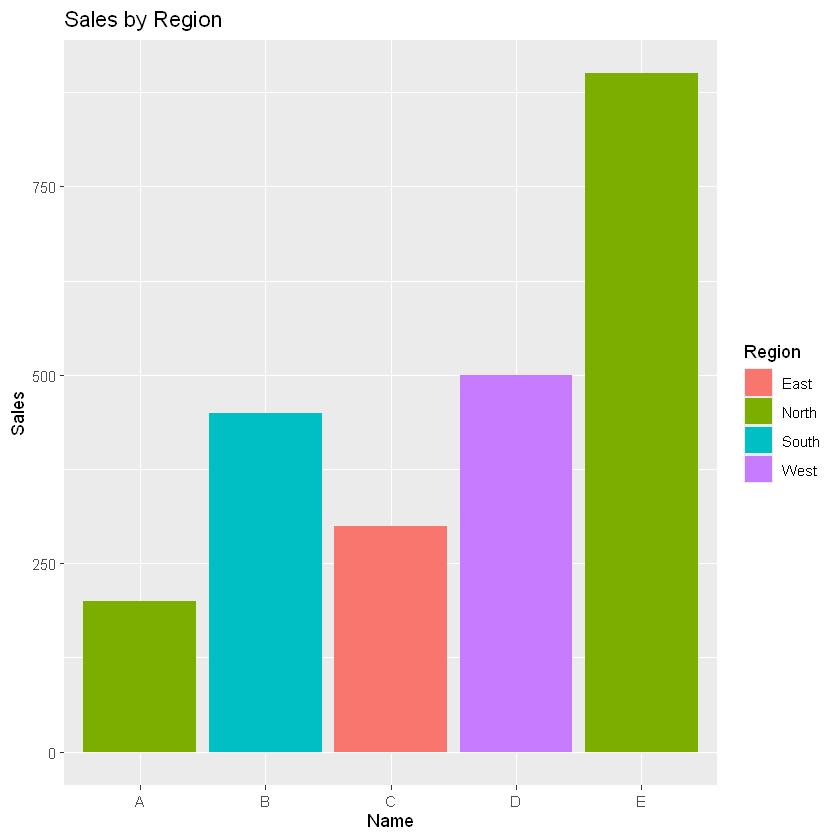

In [185]:
ggplot(data, aes(x = Name, y = Sales, fill = Region)) +
  geom_bar(stat = "identity") +
  ggtitle("Sales by Region")

🔹 4. Histogram

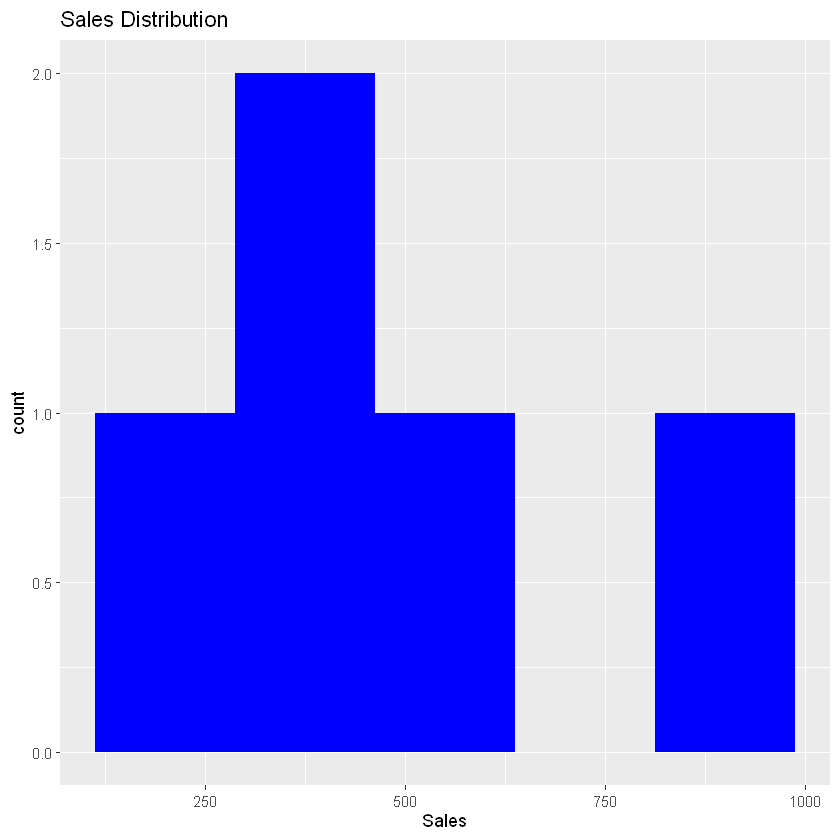

In [186]:
ggplot(data, aes(x = Sales)) +
  geom_histogram(fill = "blue", bins = 5) +
  ggtitle("Sales Distribution")

🔹 5. Box Plot (Grouped)

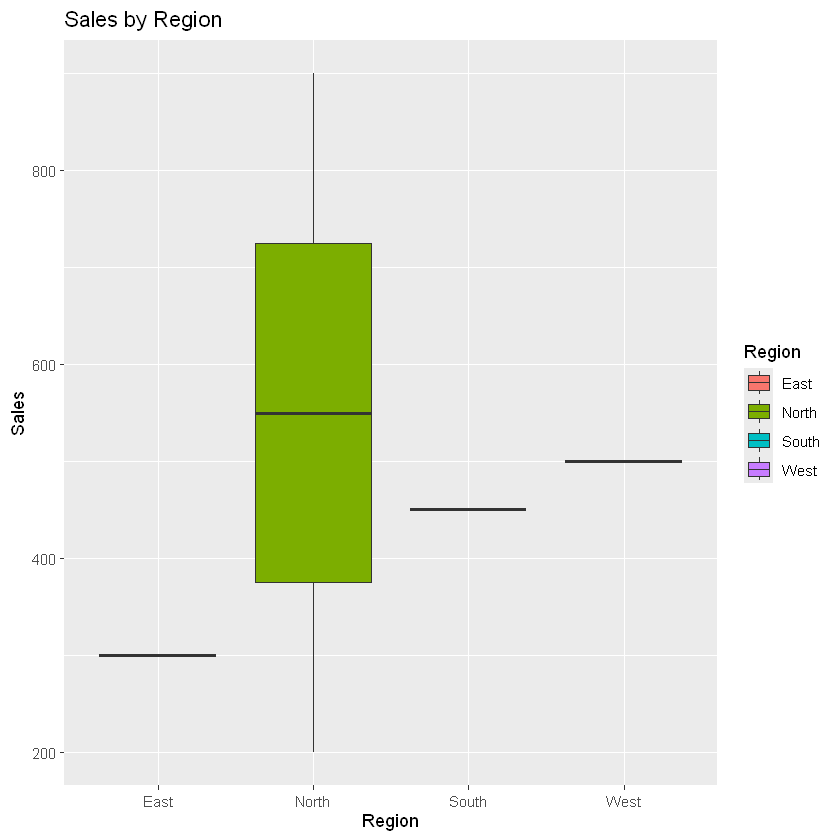

In [187]:
ggplot(data, aes(x = Region, y = Sales, fill = Region)) +
  geom_boxplot() +
  ggtitle("Sales by Region")

🔹 6. Line Chart

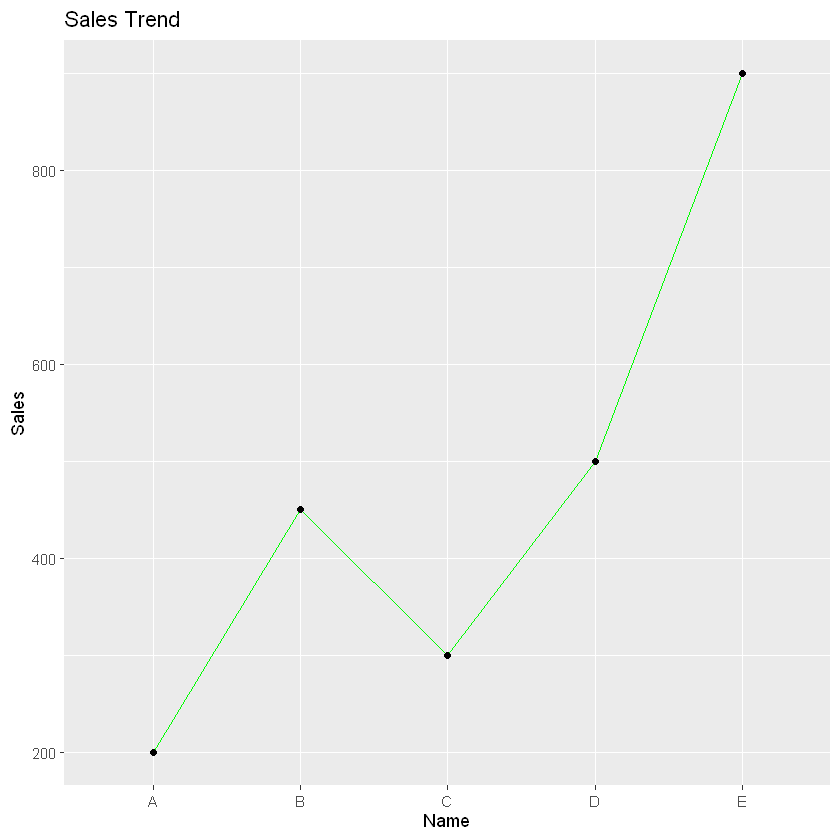

In [188]:
ggplot(data, aes(x = Name, y = Sales, group = 1)) +
  geom_line(color = "green") +
  geom_point() +
  ggtitle("Sales Trend")

🔹 7. Density Plot (Advanced Distribution)

- Better than histogram for smooth distribution

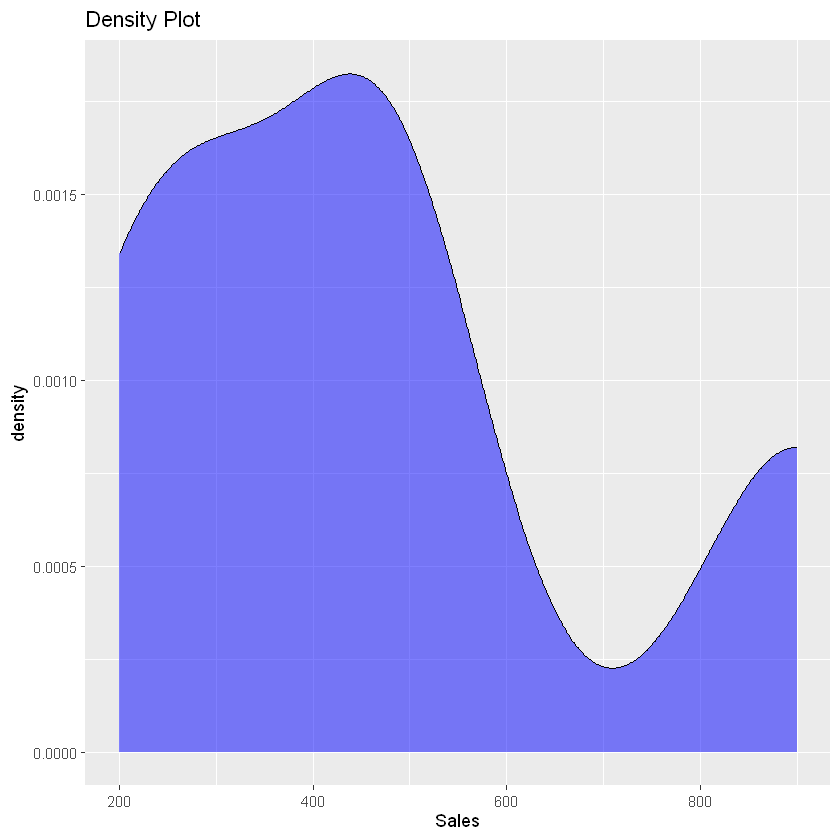

In [189]:
ggplot(data, aes(x = Sales)) +
  geom_density(fill = "blue", alpha = 0.5) +
  ggtitle("Density Plot")

# MULTIPLE PLOTS IN ONE VIEW

This is for dashboard-style visualization

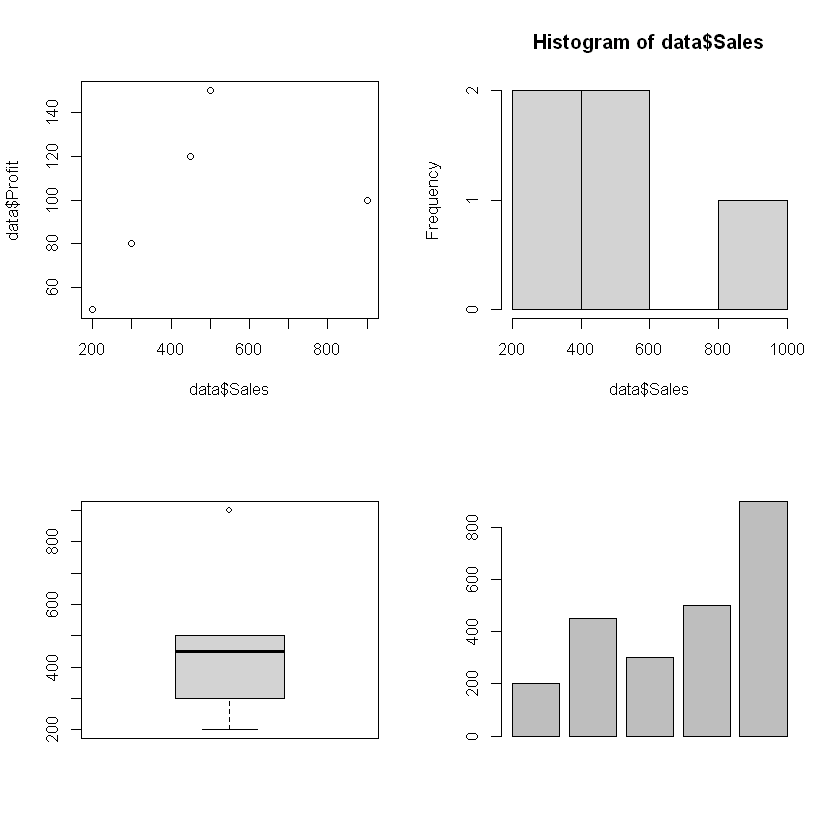

In [190]:
par(mfrow = c(2, 2))

plot(data$Sales, data$Profit)
hist(data$Sales)
boxplot(data$Sales)
barplot(data$Sales)

Data Types → Chart Type

| Data Type                | Best Chart          |
| ------------------------ | ------------------- |
| Numerical vs Numerical   | Scatter Plot        |
| Categorical vs Numerical | Bar Chart           |
| Distribution             | Histogram / Density |
| Spread                   | Box Plot            |
| Time Series              | Line Chart          |